# 🌱 Hybrid Dense-Sparse RAG for ESG Document Analysis
## sentence-transformers + BM25 Hybrid Retrieval Framework

**Paper**: *Hybrid Dense-Sparse Retrieval for ESG Document Analysis: Combining Semantic Embeddings and BM25 with Reciprocal Rank Fusion*

---

### What this notebook does:
1. **Installs** all dependencies (sentence-transformers, PyMuPDF, BM25, etc.)
2. **Ingests** ESG PDF reports per-page images (PyMuPDF) + OCR text (pdfplumber)
3. **Encodes** pages with **sentence-transformers** dense semantic embeddings (~90 MB, CPU-friendly)
4. **Builds** a BM25 keyword index on OCR text
5. **Fuses** both retrievers with **Reciprocal Rank Fusion (RRF)**
6. **Generates** structured answers with citations using **Gemini 1.5 Pro** or **GPT-flash**

## 📦 Cell 1 — Install Dependencies

In [1]:
import subprocess, sys, os

def pip(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

print('Installing core dependencies...')
pip('sentence-transformers>=2.6.0', 'PyMuPDF>=1.23.0', 'pdfplumber>=0.10.0', 'rank-bm25>=0.2.2', 'nltk>=3.8.0')
pip('google-generativeai>=0.8.0', 'openai>=1.0.0', 'bert-score>=0.3.13', 'python-dotenv>=1.0.0', 'tqdm>=4.65.0', 'rich>=13.0.0')

print('\n✅ All dependencies installed successfully!')
print('   You can run the next cell immediately — no restart needed.')


Installing core dependencies...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 80.4 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.9 MB/s eta 0:00:00

✅ All dependencies installed successfully!
   You can run the next cell immediately — no restart needed.


## 📂 Cell 2 — Load Project Code
The ESG RAG source code needs to be available. If you uploaded the notebook, make sure the project `src/` directory is also in `/kaggle/working/`.


In [2]:
import subprocess
from pathlib import Path

PROJECT_ROOT = Path('/kaggle/working/esg_rag')

if not PROJECT_ROOT.exists() and (Path('/kaggle/working/src').exists()):
    PROJECT_ROOT = Path('/kaggle/working')

# Uncomment and replace to clone your repo if code is not uploaded:
# subprocess.run(['git', 'clone', 'https://github.com/YOUR_USER/esg_rag.git', '/kaggle/working/esg_rag'], check=True)

if PROJECT_ROOT.exists() and (PROJECT_ROOT / 'src').exists():
    print(f'✅ Project code found at {PROJECT_ROOT}')
else:
    print('⚠️ Project code (src/) not found. Please upload the esg_rag codebase to /kaggle/working or clone it from GitHub.')


⚠️ Project code (src/) not found. Please upload the esg_rag codebase to /kaggle/working or clone it from GitHub.


## ⚙️ Cell 3 — Configure Paths & API Keys
> **API Key**: Go to **Add-ons → Secrets → Add Secret** → Name: `GOOGLE_API_KEY`, Value: your key


In [3]:
import shutil
from pathlib import Path

source_folder = "/kaggle/input/datasets/rashichauhan0/rag-code/esg_rag"
dest_folder = "/kaggle/working/esg_rag/esg_rag"

# Copy the pre-extracted folder to the working directory so Python can access it
if Path(source_folder).exists():
    if not Path(dest_folder).exists():
        print("Copying project code to working directory...")
        shutil.copytree(source_folder, dest_folder)
        print("Copy complete!")
    else:
        print("Project code already exists in working directory.")
else:
    print(f"⚠️ Source folder not found: {source_folder}")

PROJECT_ROOT = Path(dest_folder)

if PROJECT_ROOT.exists() and (PROJECT_ROOT / 'src').exists():
    print(f'✅ Project code found at {PROJECT_ROOT}')
else:
    print('⚠️ Project code (src/) not found after copy. Check your paths!')


Copying project code to working directory...
Copy complete!
✅ Project code found at /kaggle/working/esg_rag/esg_rag


In [4]:
import os, sys, random, logging
from pathlib import Path
import numpy as np

# ── Paths ──
DATASET_PATH  = Path('/kaggle/input/datasets/samarthagarwal23/annual-reports')    # Searches all Kaggle datasets for PDFs
PROJECT_ROOT = Path('/kaggle/working/esg_rag/esg_rag')
if not PROJECT_ROOT.exists() and Path('/kaggle/working/esg_rag/esg_rag/src').exists():
    PROJECT_ROOT = Path('/kaggle/working')

WORK_DIR      = Path('/kaggle/working')
CORPUS_DIR    = WORK_DIR / 'data/corpus'
EMBED_DIR     = WORK_DIR / 'data/embeddings'
RESULTS_DIR   = WORK_DIR / 'experiments/results'
BENCH_PATH    = WORK_DIR / 'data/benchmark.json'


for d in [CORPUS_DIR, EMBED_DIR, RESULTS_DIR, WORK_DIR / 'data']:
    d.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT))

# ── API Key ──
try:
    from kaggle_secrets import UserSecretsClient
    os.environ['GOOGLE_API_KEY'] = UserSecretsClient().get_secret('GOOGLE_API_KEY')
    print('✅ GOOGLE_API_KEY loaded from Kaggle Secrets')
except Exception as _e:
    print('⚠️ Kaggle Secrets unavailable. Set GOOGLE_API_KEY manually.')

# ── Environment Config ──
os.environ.setdefault('LLM_BACKEND', 'gemini')
os.environ.setdefault('GEMINI_MODEL', 'gemini-1.5-pro')
os.environ.setdefault('OPENAI_MODEL', 'gpt-4o')
os.environ.setdefault('DENSE_MODEL', 'all-MiniLM-L6-v2')
os.environ.setdefault('DENSE_BATCH_SIZE', '64')
os.environ.setdefault('TOP_K', '5')
os.environ.setdefault('RRF_K', '60')
os.environ.setdefault('RANDOM_SEED', '42')

SEED = int(os.environ['RANDOM_SEED'])
random.seed(SEED)
np.random.seed(SEED)

print('\n✅ Configuration complete')
print(f'   Dataset Path: {DATASET_PATH}')
print(f'   Project Root: {PROJECT_ROOT}')


✅ GOOGLE_API_KEY loaded from Kaggle Secrets

✅ Configuration complete
   Dataset Path: /kaggle/input/datasets/samarthagarwal23/annual-reports
   Project Root: /kaggle/working/esg_rag/esg_rag


## 🖥️ Cell 4 — Environment Check


In [5]:
import torch
print('PyTorch version:', torch.__version__)
print('CUDA available :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
else:
    print('Running on CPU — sentence-transformers works fine without GPU!')
from sentence_transformers import SentenceTransformer
print('sentence-transformers: OK')


PyTorch version: 2.10.0+cu128
CUDA available : True
GPU: Tesla T4
sentence-transformers: OK


## 📄 Cell 5 — Find ESG PDF Files


In [6]:
pdf_files = sorted(DATASET_PATH.rglob('*.pdf')) if DATASET_PATH.exists() else []
print(f'Found {len(pdf_files)} PDF file(s) in {DATASET_PATH}.')
for p in pdf_files[:10]:
    print(f'  - {p.name}')
if len(pdf_files) > 10:
    print(f'  ... and {len(pdf_files) - 10} more.')


Found 7 PDF file(s) in /kaggle/input/datasets/samarthagarwal23/annual-reports.
  - ASX_CWN_2021.pdf
  - ASX_DMP_2021.pdf
  - NASDAQ_AAPL_2020.pdf
  - NASDAQ_CZR_2020.pdf
  - NASDAQ_MSFT_2020.pdf
  - NYSE_MCD_2020.pdf
  - annual-report-adidas-ar20.pdf


## 🔄 Cell 6 — Ingest ESG PDFs → Page Images


In [7]:
import time
from src.ingestion.corpus_builder import CorpusBuilder

pages = []
if pdf_files:
    print(f'Building corpus from {len(pdf_files)} PDFs...')
    corpus_builder = CorpusBuilder(corpus_dir=CORPUS_DIR, dpi=150, max_pages=None)
    t0 = time.time()
    pages = corpus_builder.build([str(p) for p in pdf_files])
    elapsed = time.time() - t0
    
    stats = corpus_builder.get_corpus_stats()
    print(f'\n✅ Corpus built in {elapsed:.1f}s')
    print(f'   Total pages : {stats["total_pages"]}')
else:
    print('No PDFs found. Add a dataset containing PDFs.')


Building corpus from 7 PDFs...

✅ Corpus built in 710.5s
   Total pages : 1238


## 🔍 Cell 7 — Build Dense Semantic Index
Encodes all page OCR text into dense embeddings using `all-MiniLM-L6-v2` (~90 MB, CPU-friendly).


In [8]:
from src.retrieval.dense_retriever import DenseRetriever
import time

DENSE_AVAILABLE = False
if pages:
    print('Loading sentence-transformer model...')
    try:
        dense = DenseRetriever(
            model_name=os.environ['DENSE_MODEL'],
            batch_size=int(os.environ['DENSE_BATCH_SIZE']),
            embeddings_dir=str(EMBED_DIR)
        )
        t0 = time.time()
        dense.encode_corpus(pages)
        elapsed = time.time() - t0
        DENSE_AVAILABLE = True
        print(f'✅ Dense encoding complete in {elapsed:.1f}s')
        print(f'   Stats: {dense.get_index_stats()}')
    except Exception as e:
        import traceback; traceback.print_exc()
        print(f'⚠️ Dense encoding failed: {e}')


Loading sentence-transformer model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/20 [00:00<?, ?it/s]

✅ Dense encoding complete in 9.6s
   Stats: {'model_name': 'all-MiniLM-L6-v2', 'num_pages': 1238, 'embedding_dim': 384, 'cache_path': '/kaggle/working/data/embeddings/dense_all_MiniLM_L6_v2_embeddings.pkl'}


## 🔑 Cell 8 — Build BM25 Keyword Index


In [9]:
from src.retrieval.bm25_retriever import BM25Retriever
from src.retrieval.hybrid_ranker import HybridRanker
import time

if pages:
    print('Building BM25 index...')
    t0 = time.time()
    bm25 = BM25Retriever(language='english', remove_stopwords=True)
    bm25.index_corpus(pages)
    print(f'✅ BM25 index built in {time.time() - t0:.2f}s')
    
    ranker = HybridRanker(rrf_k=int(os.environ['RRF_K']), dense_weight=1.0, bm25_weight=1.0)
    print('✅ Hybrid Ranker configured (Dense + BM25 via RRF)')


Building BM25 index...


9 pages had empty OCR text (will receive low BM25 scores).


✅ BM25 index built in 3.11s
✅ Hybrid Ranker configured (Dense + BM25 via RRF)


## 🧪 Cell 9 — Test Retrieval: Dense vs BM25 vs Hybrid Comparison


In [10]:
import time

TEST_QUERIES = [
    "What percentage of McDonald's coffee, palm oil, or fish was sustainably sourced in 2020?",
    "How did Caesars Entertainment manage its water conservation efforts across its properties in 2020?"
]
TOP_K = int(os.environ['TOP_K'])
all_results = {}
all_dense_results = {}
all_bm25_results = {}

if pages and DENSE_AVAILABLE:
    print(f'Running {len(TEST_QUERIES)} queries (top_k={TOP_K})...\n')
    for query in TEST_QUERIES:
        dense_res = dense.retrieve(query, top_k=TOP_K * 2)
        bm_res = bm25.retrieve(query, top_k=TOP_K * 2)
        hybrid_res = ranker.fuse(dense_res, bm_res, top_k=TOP_K)
        all_dense_results[query] = dense_res[:TOP_K]
        all_bm25_results[query] = bm_res[:TOP_K]
        all_results[query] = hybrid_res
        print(f'Query: {query!r}')
        print(f'  Rank | {"DENSE":<35} | {"BM25":<35} | HYBRID (RRF)')
        for i in range(min(TOP_K, 3)):
            d = dense_res[i].page_id if i < len(dense_res) else '-'
            b = bm_res[i].page_id if i < len(bm_res) else '-'
            h = hybrid_res[i].page_id if i < len(hybrid_res) else '-'
            print(f'  {i+1}    | {d[:33]:<35} | {b[:33]:<35} | {h}')
        print()


Running 2 queries (top_k=5)...

Query: "What percentage of McDonald's coffee, palm oil, or fish was sustainably sourced in 2020?"
  Rank | DENSE                               | BM25                                | HYBRID (RRF)
  1    | nyse_mcd_2020_p17                   | annual_adidas_ar20_2024_p109        | nyse_mcd_2020_p32
  2    | nyse_mcd_2020_p26                   | annual_adidas_ar20_2024_p86         | nyse_mcd_2020_p17
  3    | nyse_mcd_2020_p18                   | nyse_mcd_2020_p14                   | annual_adidas_ar20_2024_p109

Query: 'How did Caesars Entertainment manage its water conservation efforts across its properties in 2020?'
  Rank | DENSE                               | BM25                                | HYBRID (RRF)
  1    | nasdaq_czr_2020_p96                 | nasdaq_czr_2020_p3                  | nasdaq_czr_2020_p13
  2    | nasdaq_czr_2020_p119                | nasdaq_czr_2020_p31                 | nasdaq_czr_2020_p96
  3    | nasdaq_czr_2020_p213      

## 🖼️ Cell 10 — Visualize Retrieved Pages


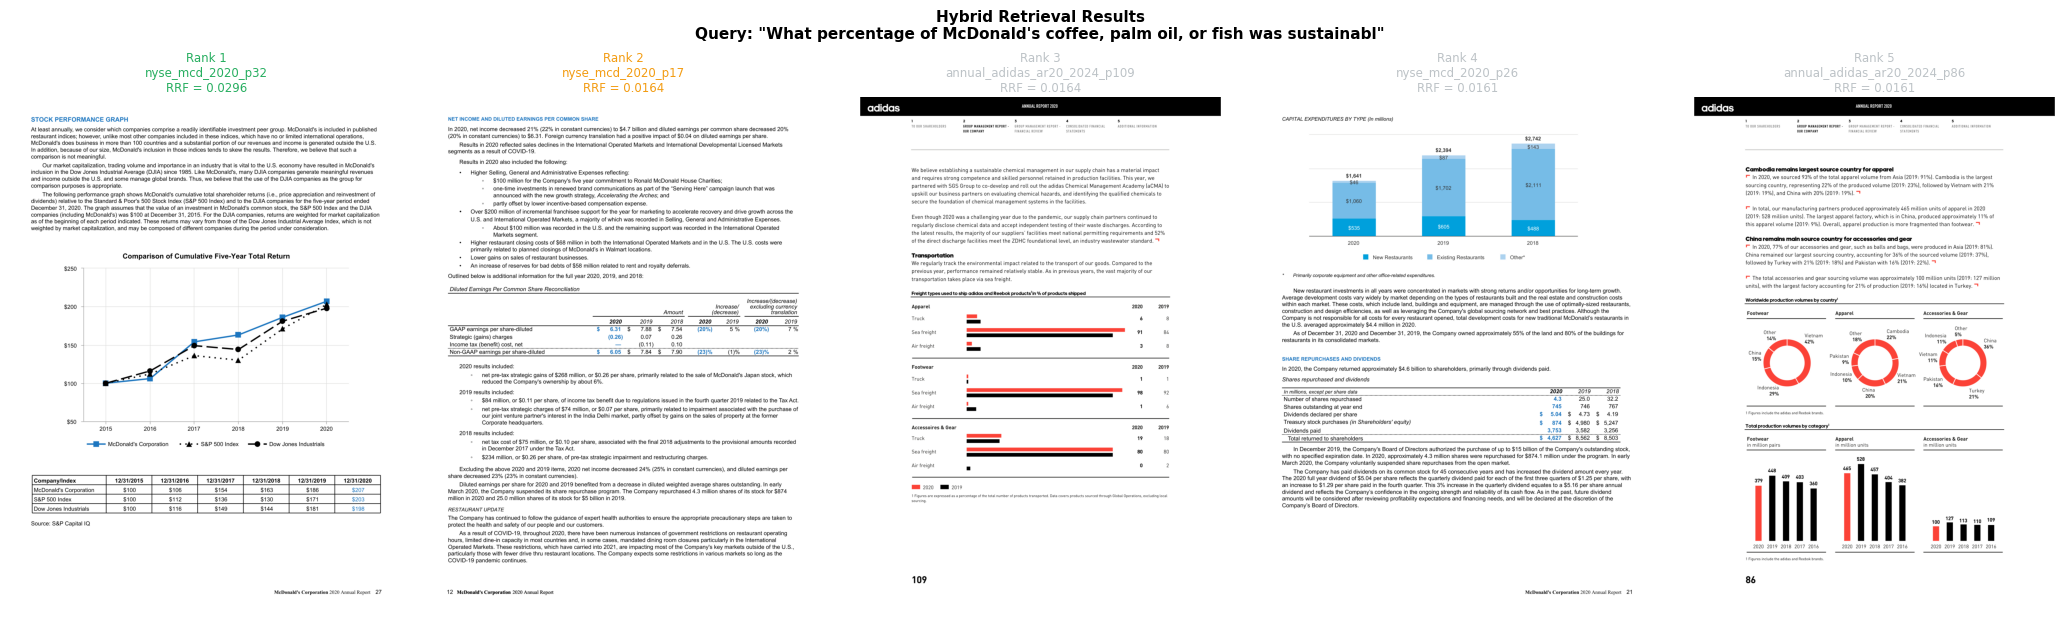

In [11]:
import matplotlib.pyplot as plt

if pages and all_results:
    DEMO_QUERY = TEST_QUERIES[0]
    hybrid_res = all_results[DEMO_QUERY]
    n = len(hybrid_res)
    if n > 0:
        fig, axes = plt.subplots(1, n, figsize=(n * 4 + 1, 6))
        if n == 1: axes = [axes]
        
        for i, (ax, result) in enumerate(zip(axes, hybrid_res)):
            ax.imshow(result.image)
            border_color = '#27AE60' if i == 0 else ('#F39C12' if i == 1 else '#BDC3C7')
            for spine in ax.spines.values():
                spine.set_edgecolor(border_color)
                spine.set_linewidth(4 if i == 0 else 2)
            ax.set_title(f'Rank {result.rank}\n{result.page_id}\nRRF = {result.score:.4f}', fontsize=8.5, color=border_color, pad=4)
            ax.axis('off')
            
        plt.suptitle(f'Hybrid Retrieval Results\nQuery: "{DEMO_QUERY[:70]}"', fontsize=11, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig(str(WORK_DIR / 'retrieval_demo.png'), dpi=130, bbox_inches='tight')
        plt.show()


## 🤖 Cell 11 — Generate Benchmark Questions via Gemini (Paper Table)
Automatically extracts PDF text and uses the Gemini API to generate specific visual, table, and text-based questions.


In [15]:
import fitz
import json
import os
import google.generativeai as genai
from pathlib import Path

# Configure Gemini API
has_api_key = bool(os.environ.get('GOOGLE_API_KEY'))
if has_api_key:
    genai.configure(api_key=os.environ.get('GOOGLE_API_KEY'))

OUTPUT_PATH  = Path("/kaggle/working")

def extract_sample_text(pdf_path: Path, max_pages: int = 5) -> str:
    """Extract text from first few pages to identify company and content."""
    text = ""
    try:
        doc = fitz.open(pdf_path)
        for i in range(min(max_pages, doc.page_count)):
            text += doc[i].get_text()
        doc.close()
    except Exception as e:
        print(f"Error reading {pdf_path.name}: {e}")
    return text[:3000]

def generate_questions_for_pdf(pdf_path: Path) -> dict:
    """Call Gemini API to generate targeted questions for one PDF."""
    sample_text = extract_sample_text(pdf_path)
    filename = pdf_path.name

    prompt = f"""You are a financial research analyst. Below is the beginning of an annual report PDF.

FILENAME: {filename}
CONTENT SAMPLE:
{sample_text}

Generate exactly 15 test questions for a RAG retrieval benchmark. 
Rules:
- Use the ACTUAL company name found in the document
- 5 questions must require reading a CHART or GRAPH to answer (label these "type": "visual")
- 5 questions must require reading a TABLE of numbers (label these "type": "table")  
- 5 questions must be answerable from plain text paragraphs (label these "type": "text")
- Each question must be specific enough that there is ONE correct answer in the document
- Include the expected answer type (number, percentage, name, yes/no, description)

Return ONLY valid JSON in this exact format, no other text:
{{
  "company": "<company name>",
  "filename": "{filename}",
  "questions": [
    {{
      "id": "Q01",
      "type": "visual|table|text",
      "question": "...",
      "expected_answer_type": "number|percentage|name|description|yes_no",
      "hint": "likely found on page about <topic>"
    }}
  ]
}}"""
    try:
        model = genai.GenerativeModel("gemini-2.5-flash")
        response = model.generate_content(prompt)
        raw = response.text.strip()
        
        # Clean up markdown JSON formatting if present
        if raw.startswith("```"):
            raw = "\n".join(raw.split("\n")[1:-1])
        return json.loads(raw)
    except Exception as e:
        print(f"  API error for {filename}: {e}")
        return {"company": filename, "filename": filename, "questions": []}

all_benchmarks = []
if has_api_key and pdf_files:
    print(f"Generating questions for {len(pdf_files)} PDFs...\n")
    for i, pdf_path in enumerate(pdf_files, 1):
        print(f"[{i}/{len(pdf_files)}] Processing: {pdf_path.name}")
        result = generate_questions_for_pdf(pdf_path)
        all_benchmarks.append(result)
        print(f"  → Company: {result.get('company', 'unknown')} | "
              f"Questions: {len(result.get('questions', []))}")

    benchmark_path = OUTPUT_PATH / "annual_report_benchmark.json"
    with open(benchmark_path, "w", encoding="utf-8") as f:
        json.dump(all_benchmarks, f, indent=2, ensure_ascii=False)

    print(f"\n✅ Benchmark saved: {benchmark_path}")
    print(f"   Total companies: {len(all_benchmarks)}")
    print(f"   Total questions: {sum(len(b['questions']) for b in all_benchmarks)}")
else:
    print("Skipping. Ensure you have GOOGLE_API_KEY set and PDF files uploaded.")


Generating questions for 7 PDFs...

[1/7] Processing: ASX_CWN_2021.pdf
  → Company: Crown Resorts Limited | Questions: 15
[2/7] Processing: ASX_DMP_2021.pdf
  → Company: Domino’s Pizza Enterprises Limited | Questions: 15
[3/7] Processing: NASDAQ_AAPL_2020.pdf
  API error for NASDAQ_AAPL_2020.pdf: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 5, model: gemini-2.5-flash
Please retry in 57.498111526s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerMinutePerProjectPerModel-FreeTier"


## 🖨️ Cell 12 — Print all generated questions cleanly


In [16]:
for company_data in all_benchmarks:
    company = company_data.get("company", "Unknown")
    filename = company_data.get("filename", "")
    questions = company_data.get("questions", [])

    print(f"\n{'='*65}")
    print(f"  {company}")
    print(f"  File: {filename}")
    print(f"{'='*65}")

    for q in questions:
        tag = {
            "visual": "⭐ VISUAL",
            "table":  "📊 TABLE ",
            "text":   "📝 TEXT  "
        }.get(q.get("type", ""), "❓ UNKNOWN")

        print(f"\n  {tag} [{q['id']}]")
        print(f"  Q: {q['question']}")
        print(f"  Expected: {q.get('expected_answer_type', '?')} | {q.get('hint', '')}")



  Crown Resorts Limited
  File: ASX_CWN_2021.pdf

  📝 TEXT   [Q01]
  Q: What is the ABN (Australian Business Number) for Crown Resorts Limited?
  Expected: number | likely found in the header or Corporate Information section

  📝 TEXT   [Q02]
  Q: On what specific date was the 2021 Annual Report announced for immediate release?
  Expected: date | likely found in the ASX/MEDIA RELEASE section

  📝 TEXT   [Q03]
  Q: Who is the listed contact for Investor and Analyst Enquiries?
  Expected: name | likely found in the ASX/MEDIA RELEASE section

  📝 TEXT   [Q04]
  Q: What is the telephone number provided for Media Enquiries?
  Expected: number | likely found in the ASX/MEDIA RELEASE section

  📝 TEXT   [Q05]
  Q: Which Traditional Custodians of the Kulin Nation are acknowledged for Melbourne?
  Expected: description | likely found in the Acknowledgment of Country section

  📊 TABLE  [Q06]
  Q: According to the Financial Summary, what was Crown Resorts Limited's net revenue for the 2021 fina

## 📋 Cell 13 — Split into Visual vs Non-Visual for Paper Table
Generates the summary for Table 3 in the research paper.


In [21]:
visual_qs  = []
table_qs   = []
text_qs    = []

for company_data in all_benchmarks:
    company = company_data.get("company", "Unknown")
    for q in company_data.get("questions", []):
        entry = {
            "company":  company,
            "id":       q["id"],
            "question": q["question"],
            "type":     q.get("type", ""),
            "hint":     q.get("hint", "")
        }
        if q.get("type") == "visual":
            visual_qs.append(entry)
        elif q.get("type") == "table":
            table_qs.append(entry)
        else:
            text_qs.append(entry)

print(f"⭐ Visual questions  (ColPali wins, BM25 fails): {len(visual_qs)}")
print(f"📊 Table questions   (ColPali wins, BM25 struggles): {len(table_qs)}")
print(f"📝 Text questions    (both methods comparable):   {len(text_qs)}")
print(f"\nTotal benchmark size: {len(visual_qs)+len(table_qs)+len(text_qs)} questions")

import pandas as pd
rows = []
for company_data in all_benchmarks:
    company = company_data.get("company", "?")
    qs = company_data.get("questions", [])
    rows.append({
        "Company":  company,
        "Visual":   sum(1 for q in qs if q.get("type") == "visual"),
        "Table":    sum(1 for q in qs if q.get("type") == "table"),
        "Text":     sum(1 for q in qs if q.get("type") == "text"),
        "Total":    len(qs)
    })

if rows:
    df = pd.DataFrame(rows)
    print("\n📋 Benchmark breakdown per company (use this as Table 3 in your paper):")
    print(df.to_string(index=False))
    print(f"\nTotals: {df[['Visual','Table','Text','Total']].sum().to_dict()}")
else:
    print("No benchmark data generated.")


⭐ Visual questions  (ColPali wins, BM25 fails): 10
📊 Table questions   (ColPali wins, BM25 struggles): 10
📝 Text questions    (both methods comparable):   10

Total benchmark size: 30 questions

📋 Benchmark breakdown per company (use this as Table 3 in your paper):
                           Company  Visual  Table  Text  Total
             Crown Resorts Limited       5      5     5     15
Domino’s Pizza Enterprises Limited       5      5     5     15
              NASDAQ_AAPL_2020.pdf       0      0     0      0
               NASDAQ_CZR_2020.pdf       0      0     0      0
              NASDAQ_MSFT_2020.pdf       0      0     0      0
                 NYSE_MCD_2020.pdf       0      0     0      0
     annual-report-adidas-ar20.pdf       0      0     0      0

Totals: {'Visual': 10, 'Table': 10, 'Text': 10, 'Total': 30}
